In [1]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Setup successful")

Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
Setup successful


In [2]:
from google.colab import files
uploaded = files.upload()

Saving ped.jpg to ped.jpg


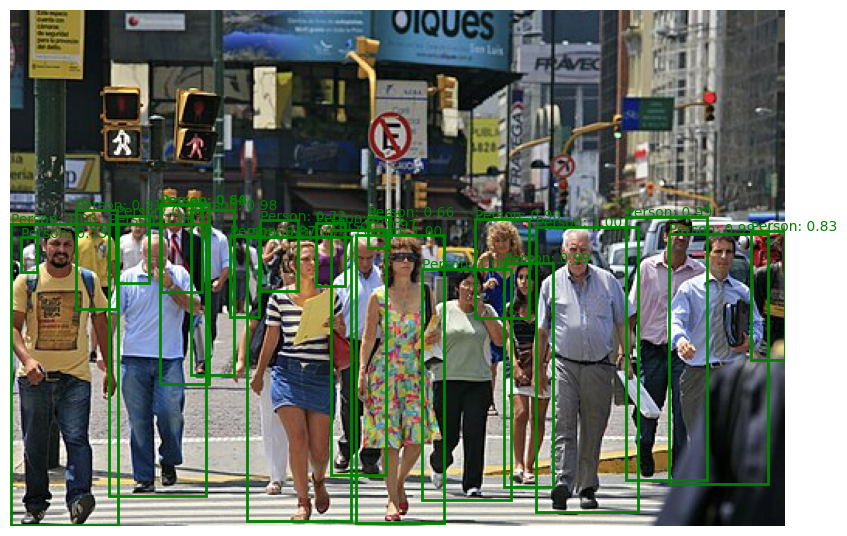

In [9]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load pre-trained Faster R-CNN model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

# Load image
image = Image.open("ped.jpg").convert("RGB")

# Transform image
transform = transforms.ToTensor()
img = transform(image)

# Run model
with torch.no_grad():
    predictions = model([img])

# Get results
boxes = predictions[0]['boxes']
labels = predictions[0]['labels']
scores = predictions[0]['scores']

# Plot image
fig, ax = plt.subplots(1, figsize=(10, 8))
ax.imshow(image)

person_found = False

# Draw boxes
for i in range(len(boxes)):
    if labels[i] == 1 and scores[i] > 0.5:  # 1 = person
        person_found = True
        box = boxes[i].numpy()
        x1, y1, x2, y2 = box

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='green',
            facecolor='none'
        )
        ax.add_patch(rect)

        ax.text(x1, y1, f'Person: {scores[i]:.2f}',
                color='green', fontsize=10)

if not person_found:
    print("No person detected.")

plt.axis('off')
plt.show()

In [4]:
from google.colab import files
uploaded = files.upload()

Saving pedistrain.png to pedistrain.png


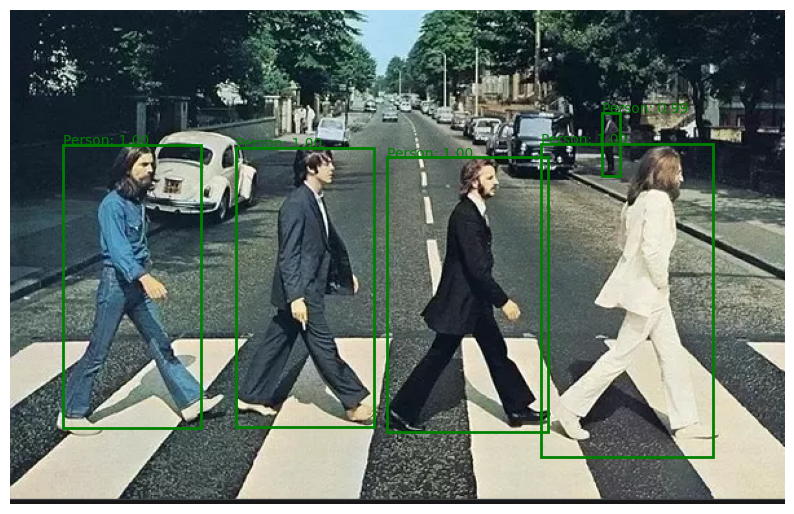

In [5]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load pre-trained Faster R-CNN model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

# Load image
image = Image.open("pedistrain.png").convert("RGB")

# Transform image
transform = transforms.ToTensor()
img = transform(image)

# Run model
with torch.no_grad():
    predictions = model([img])

# Get results
boxes = predictions[0]['boxes']
labels = predictions[0]['labels']
scores = predictions[0]['scores']

# Plot image
fig, ax = plt.subplots(1, figsize=(10, 8))
ax.imshow(image)

person_found = False

# Draw boxes
for i in range(len(boxes)):
    if labels[i] == 1 and scores[i] > 0.5:  # 1 = person
        person_found = True
        box = boxes[i].numpy()
        x1, y1, x2, y2 = box

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='green',
            facecolor='none'
        )
        ax.add_patch(rect)

        ax.text(x1, y1, f'Person: {scores[i]:.2f}',
                color='green', fontsize=10)

if not person_found:
    print("No person detected.")

plt.axis('off')
plt.show()

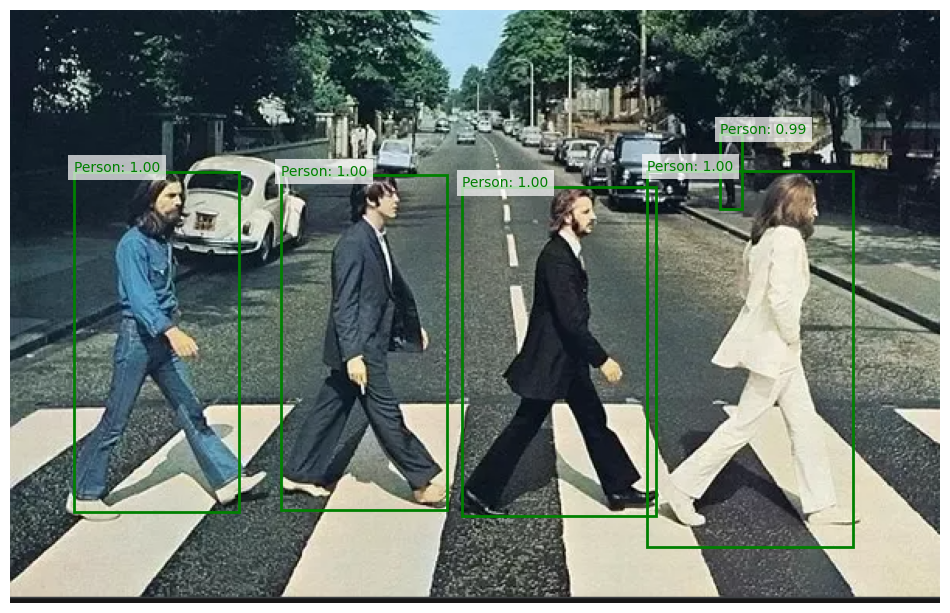

Saved as detected_output.png


In [7]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load pre-trained Faster R-CNN model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

# Load image
image = Image.open("pedistrain.png").convert("RGB")

# Transform image
transform = transforms.ToTensor()
img = transform(image)

# Run model
with torch.no_grad():
    predictions = model([img])

boxes = predictions[0]['boxes']
labels = predictions[0]['labels']
scores = predictions[0]['scores']

fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(image)

for i in range(len(boxes)):
    if labels[i] == 1 and scores[i] > 0.5:
        box = boxes[i].numpy()
        x1, y1, x2, y2 = box

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='green',
            facecolor='none'
        )
        ax.add_patch(rect)

        ax.text(x1, y1, f'Person: {scores[i]:.2f}',
                color='green', fontsize=10,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.axis('off')
plt.savefig("detected_output.png", bbox_inches='tight', pad_inches=0.1)
plt.show()

print("Saved as detected_output.png")

In [10]:
person_count = 0
confidences = []

for i in range(len(boxes)):
    if labels[i] == 1 and scores[i] > 0.5:
        person_count += 1
        confidences.append(scores[i].item())

print("Total persons detected:", person_count)
print("Confidence scores:", confidences)

Total persons detected: 22
Confidence scores: [0.999403715133667, 0.9989342093467712, 0.9986357092857361, 0.9982953667640686, 0.9979780316352844, 0.9975569248199463, 0.9939751029014587, 0.9911950826644897, 0.9856323003768921, 0.9778047204017639, 0.9672917127609253, 0.9130046367645264, 0.9007816314697266, 0.8791763186454773, 0.8684732913970947, 0.8365699648857117, 0.8296626806259155, 0.8279567956924438, 0.7313752174377441, 0.7168464064598083, 0.678954541683197, 0.659239649772644]


In [11]:
import time

start = time.time()

with torch.no_grad():
    predictions = model([img])

end = time.time()

fps = 1 / (end - start)

print("FPS:", fps)

FPS: 0.19551305358254267
